In [ ]:
# SPDX-License-Identifier: LicenseRef-AI-Agents-for-LCA-Noncommercial
"""
Agentic LCA - Example demonstrating converting an internal image to PCB dimensions and components

Part of the codebase accompanying:
"Sustainability assessment using multimodal artificial intelligence agents"
Nature Electronics (2026)

See the LICENSE file in the repository root for details.
"""

import os
import cv2
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from IPython.display import clear_output
from mpl_toolkits.axes_grid1 import ImageGrid

from agentic_lci.retrieval.vision.yolo_pcb_detection import detect_pcb_axis_aligned_bounding_boxes
from agentic_lci.retrieval.vision.pcb_bounding_boxes import (
    crop,
    generate_character_boxes,
    generate_edge_boxes,
    generate_sam_masks,
    select_pcb_with_most_components,
    shrink_bounding_box,
    find_ruler_candidates,
    select_best_ruler_candidate,
    crop_and_rotate_horizontal,
    read_ruler_with_ocr,
)
from agentic_lci.retrieval.vision.yolo_pcb_segmentation import segment

import pytesseract
pytesseract.pytesseract.tesseract_cmd = '/opt/homebrew/bin/tesseract' # NOTE: set based on your system

clear_output()

## Input Image

In [2]:
# NOTE: change to select input image
INPUT_IMG_PATH = os.path.join("vision_example.jpg")

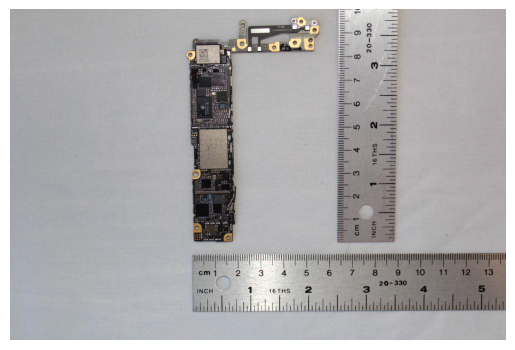

In [3]:
# Load Image
image = Image.open(INPUT_IMG_PATH)
image = np.array(image)
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
plt.imshow(image)
plt.axis('off')
plt.show()

## Detect Useful Parts of the Image

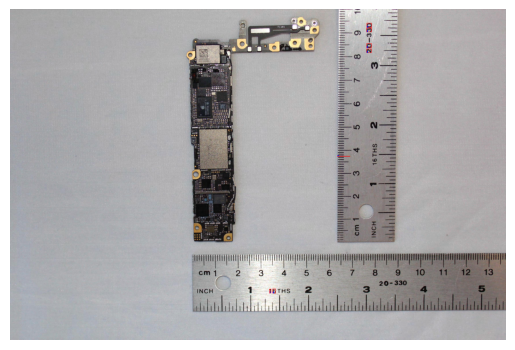

In [4]:
# Find areas with numbers (useful for identifying rulers and other areas of interest)
character_boxes, character_image = generate_character_boxes(image)
plt.imshow(character_image)
plt.axis('off')
plt.show()

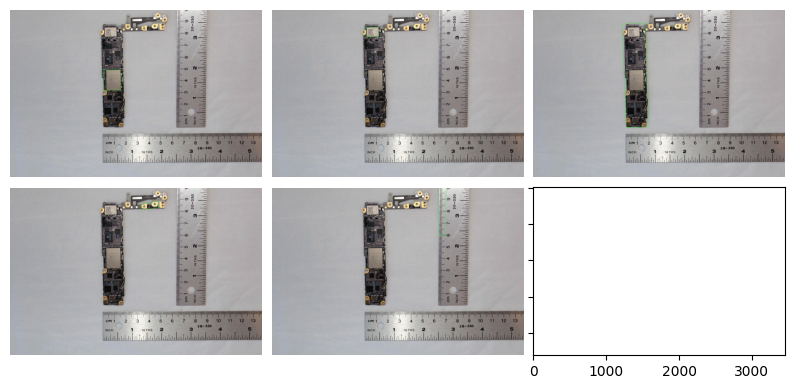

In [5]:
# Use edge detection to find candidate bounding boxes
contour_boxes, countour_images = generate_edge_boxes(image)
from math import ceil
fig = plt.figure(figsize=(10., 10.))
grid = ImageGrid(
    fig, 111,
    nrows_ncols=(ceil(len(countour_images) / 3), 3),
    axes_pad=0.1,
)

for ax, im in zip(grid, countour_images): # type: ignore
    ax.imshow(im)
    ax.axis('off')

plt.show()

In [6]:
# Other candidates can be found using segment anything
masks, mask_images = generate_sam_masks(image)
# masks = [] # NOTE: optionally disable SAM for faster inference at a slight accuracy loss

## Find the PCB


0: 448x640 1 PCB, 73.6ms
Speed: 8.6ms preprocess, 73.6ms inference, 6.1ms postprocess per image at shape (1, 3, 448, 640)


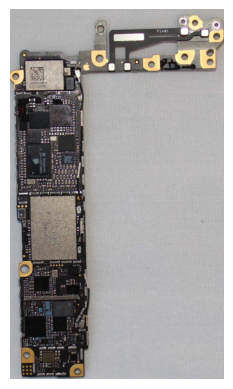

In [7]:
# Try to use custom YOLO to identify the PCB
THRESHOLD = 0.5 # NOTE: adjust the confidence threshold here
detected_pcb = detect_pcb_axis_aligned_bounding_boxes(image)
if detected_pcb is not None and len(detected_pcb.xyxy) > 0 and detected_pcb.conf[0] > THRESHOLD:
    pcb_box = detected_pcb.xyxy[0]
    pcb_box = (int(pcb_box[0]), int(pcb_box[1])), (int(pcb_box[2]), int(pcb_box[3]))
    just_pcb_image = crop(image, pcb_box[0], pcb_box[1])
else:
    # Fall back to heuristic method if the custom YOLO is not confident enough
    pcb_p1, pcb_p2, image_with_pcb_highlighted = select_pcb_with_most_components(
        image, masks, contour_boxes
    )
    pcb_box, just_pcb_image = shrink_bounding_box(pcb_p1, pcb_p2, image)

plt.imshow(just_pcb_image)
plt.axis('off')
plt.show()

## Estimate the Pixel-to-Distance Ratio Using Rulers
Replace this with an LLM tool call or known-component estimation if rulers cannot be assumed to be present

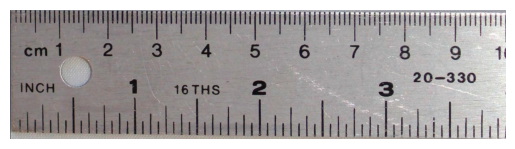

In [8]:
# Identify a visible ruler
candidate_rulers = find_ruler_candidates(
    image, masks, contour_boxes, character_boxes
)
ruler_p1, ruler_p2, image_with_ruler_highlighted = select_best_ruler_candidate(
    image, candidate_rulers, pcb_box, character_boxes
)
just_ruler_image = crop_and_rotate_horizontal(image, ruler_p1, ruler_p2)

plt.imshow(just_ruler_image)
plt.axis('off')
plt.show()

In [9]:
# Read the ruler
# NOTE: VLMs can sometimes be better than OCR (especially with unit detection)
pixelsPerInch = read_ruler_with_ocr(image, just_ruler_image)
pixelsPerMM = pixelsPerInch / 25.4
pcb_width, pcb_height = (
    just_pcb_image.shape[1] / pixelsPerMM,
    just_pcb_image.shape[0] / pixelsPerMM,
)

print(f"PCB Width: {pcb_width}mm")
print(f"PCB Height: {pcb_height}mm")

PCB Width: 37.68158866995074mm
PCB Height: 65.19772167487685mm


## Identify the Components of the PCB

In [10]:
components = segment(just_pcb_image)
for pred in components["predictions"]:
    w, h = (
        int(pred["width"]),
        int(pred["height"]),
    )
    confidence, category = pred["confidence"], pred["class"]
    print(
        f"{category} ({confidence:.2f}): {w / pixelsPerMM:.2f}mm x {h / pixelsPerMM:.2f}mm"
    )

IC (0.85): 1.55mm x 2.00mm
Capacitor Jumper (0.83): 2.04mm x 2.12mm
IC (0.82): 3.63mm x 3.88mm
Capacitor Jumper (0.82): 0.86mm x 0.98mm
Connector (0.81): 1.63mm x 2.45mm
IC (0.80): 3.18mm x 3.23mm
IC (0.80): 1.39mm x 1.59mm
IC (0.79): 0.73mm x 2.25mm
Resistor Jumper (0.78): 0.94mm x 1.27mm
IC (0.78): 1.63mm x 2.49mm
Connector (0.77): 1.59mm x 1.92mm
IC (0.75): 3.84mm x 2.90mm
IC (0.73): 2.08mm x 2.29mm
Capacitor (0.70): 0.49mm x 0.86mm
Capacitor (0.70): 1.67mm x 2.20mm
IC (0.69): 1.35mm x 1.39mm
IC (0.69): 2.37mm x 2.12mm
Connector (0.69): 2.12mm x 2.29mm
Capacitor Jumper (0.68): 1.02mm x 0.90mm
IC (0.68): 1.06mm x 2.12mm
Resistor Jumper (0.65): 0.73mm x 0.90mm
Capacitor (0.64): 1.02mm x 1.59mm
Electrolytic Capacitor (0.61): 1.84mm x 2.33mm
Connector (0.61): 1.35mm x 1.27mm
Capacitor Jumper (0.60): 0.86mm x 1.43mm
IC (0.60): 0.98mm x 1.27mm
Resistor Network (0.58): 0.53mm x 0.82mm
Capacitor Jumper (0.56): 0.65mm x 0.98mm
Connector (0.54): 1.76mm x 2.16mm
Connector (0.53): 0.82mm x 0.98

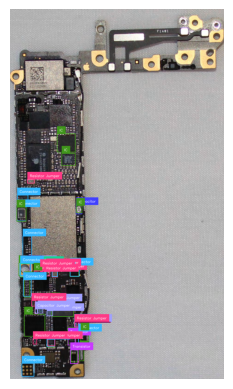

In [11]:
plt.imshow(components['annotated_image'])
plt.axis('off')
plt.show()